# Two kinds of uncertainty: epistemic vs. aleatoric
### Or: the difference between *I don't know yet* and *nobody can know*

Every prediction a model makes carries two distinct kinds of error, and
they behave completely differently. Confusing them — reporting one
number called "confidence" — is one of the most common ways a model
ends up misleading the people using it.

This notebook builds them both, in pure NumPy, with backprop written by
hand. We start from a single regression problem that contains both
sources of error, isolate each one with a different technique, and end
with one plot that separates them visually. Then we point the same lens
at LLMs and at predictive analytics, because the distinction matters in
exactly the same way in both.

Dependencies: `numpy`, `matplotlib`. No PyTorch, no autograd — every
gradient is computed explicitly so the math stays visible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# Dark theme to match the rest of the project
for k, v in {
    'figure.facecolor': '#0b0b14', 'axes.facecolor': '#0b0b14',
    'axes.edgecolor': '#444',     'axes.labelcolor': '#ddd',
    'xtick.color': '#888',         'ytick.color': '#888',
    'text.color': '#ddd',          'axes.titlecolor': '#eee',
    'legend.facecolor': '#0b0b14','legend.edgecolor': '#444',
    'legend.labelcolor': '#ddd',
}.items():
    plt.rcParams[k] = v

# Two colors used consistently throughout:
CYAN  = '#62d4ff'   # epistemic — "fog of ignorance"
GOLD  = '#ffb84a'   # aleatoric — "irreducible noise"
WHITE = '#eeeeee'

## 1. Two errors that look the same on a graph

Suppose you fit a model and at some point `x` it predicts `ŷ = 2.3 ± 1.1`.
That `±1.1` is the prediction's uncertainty. Where did it come from? There
are exactly two possibilities, and they are not interchangeable:

- **Aleatoric uncertainty** — *the world itself is noisy at this `x`.*
  Two measurements taken under identical conditions give different `y`.
  No model, no matter how good, can collapse this to zero. (From Latin
  *alea*, "dice.")

- **Epistemic uncertainty** — *the model hasn't seen enough to know the
  answer here.* You have no training data near this `x`, or your network
  is too small, or your hypothesis class is too narrow. More data, bigger
  model, better prior — this shrinks. (From Greek *epistēmē*, "knowledge.")

On a single chart they look identical: both show up as a wider error band
around the prediction. They are very different things, and they call for
very different responses.

We're going to build a dataset that exhibits both, isolate each one with
a different technique, and then combine them on a single plot.

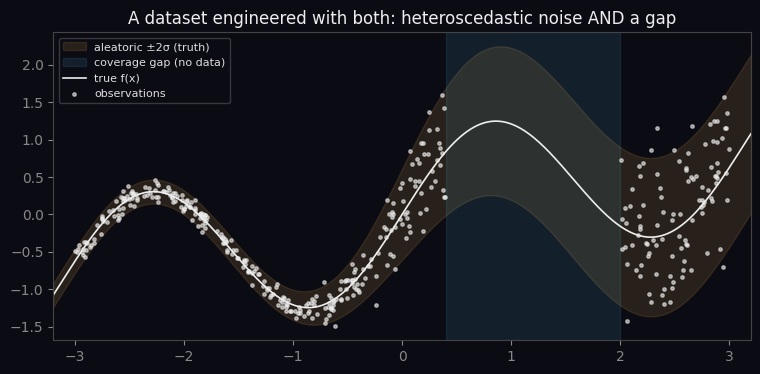

In [2]:
def true_f(x):
    """The function the world is computing."""
    return np.sin(2 * x) + 0.3 * x

def noise_std(x):
    """Aleatoric — how noisy is the world at this x?
    Smoothly larger on the right half: simulates a measurement that
    becomes inherently more variable as x grows.
    """
    return 0.08 + 0.45 * (1 + np.tanh(1.5 * x)) / 2

def make_data(n=400, gap=(0.4, 2.0), seed=0):
    """Training data with two intentional twists:
      (a) noise std grows with x   → aleatoric uncertainty present everywhere,
                                     larger on the right;
      (b) a hole in [0.4, 2.0]    → epistemic uncertainty over that gap.
    """
    rng = np.random.default_rng(seed)
    x = rng.uniform(-3, 3, size=n * 3)
    x = x[(x < gap[0]) | (x > gap[1])][:n]    # carve out the hole
    y = true_f(x) + rng.normal(0, noise_std(x))
    return x[:, None], y[:, None]

X_train, y_train = make_data(n=400)
x_grid = np.linspace(-3.2, 3.2, 400)[:, None]
g = x_grid.ravel()

fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(g, true_f(g) - 2*noise_std(g), true_f(g) + 2*noise_std(g),
                color=GOLD, alpha=0.12, label='aleatoric ±2σ (truth)')
ax.axvspan(0.4, 2.0, color=CYAN, alpha=0.10, label='coverage gap (no data)')
ax.plot(g, true_f(g), color=WHITE, linewidth=1.2, label='true f(x)')
ax.scatter(X_train, y_train, s=6, color=WHITE, alpha=0.6, label='observations')
ax.set_xlim(-3.2, 3.2); ax.legend(loc='upper left', frameon=True, fontsize=8)
ax.set_title('A dataset engineered with both: heteroscedastic noise AND a gap')
plt.show()

## 2. Aleatoric: the world flipping a coin

If you stand at the same `x` and measure `y` over and over, you get a
*distribution*, not a number. Aleatoric uncertainty is the spread of that
distribution. It depends on `x` — that's "heteroscedastic" noise, and it's
the realistic case in nature.

A useful sanity check: aleatoric uncertainty would exist even with
infinite training data. You can't average it away. Below we sample 2000
observations at two different `x` values to make the spread visible.

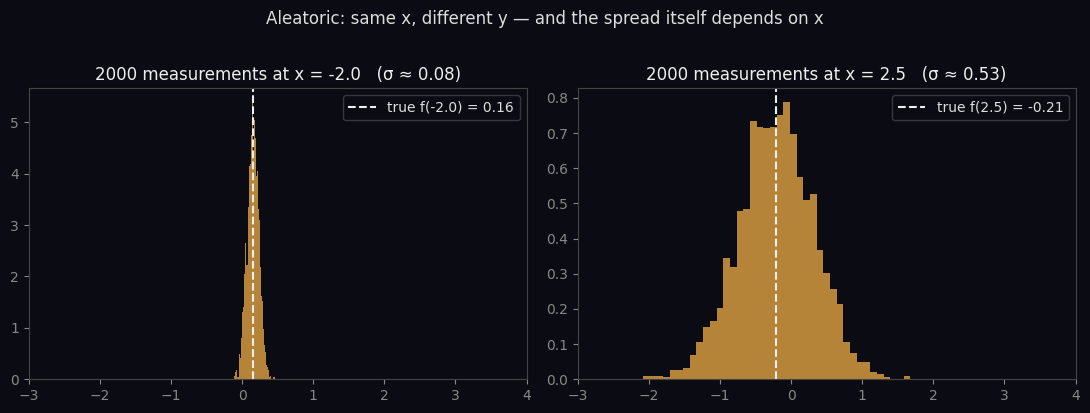

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, x0 in zip(axes, [-2.0, 2.5]):
    ys = true_f(x0) + np.random.normal(0, noise_std(x0), size=2000)
    ax.hist(ys, bins=40, color=GOLD, alpha=0.7, density=True)
    ax.axvline(true_f(x0), color=WHITE, linestyle='--', label=f'true f({x0}) = {true_f(x0):.2f}')
    ax.set_title(f'2000 measurements at x = {x0}   (σ ≈ {noise_std(x0):.2f})')
    ax.legend()
    ax.set_xlim(-3, 4)
fig.suptitle('Aleatoric: same x, different y — and the spread itself depends on x', y=1.02)
plt.tight_layout(); plt.show()

## 3. Epistemic: the model is guessing where it hasn't looked

Epistemic uncertainty is about the *model*, not the world. If you train
two sensible models on the same data, they'll agree where data was dense
and disagree where data was sparse. That disagreement is epistemic
uncertainty — and unlike aleatoric, it shrinks as you add data.

To measure it, we need an actual model. Let's build the small MLP we'll
reuse for the rest of the notebook.

## 4. A tiny MLP, two heads, by hand

The same one-hidden-layer architecture handles both jobs. The only
difference is the output:

- **MSE version** — one output `ŷ(x)`. Trained to minimize squared error.
  We'll train an ensemble of these to get *epistemic* uncertainty.

- **Heteroscedastic NLL version** — two outputs `(μ(x), s(x))`, where
  `s = log σ²`. Trained to minimize the Gaussian negative log-likelihood
  $$\mathcal{L} = \tfrac{1}{2}\bigl((y - \mu)^2 e^{-s} + s\bigr).$$
  The `μ` head learns the mean; the `s` head learns how noisy the world
  is at each `x`. That `e^s` is the *aleatoric* variance estimate.

Backprop for both is a few lines — written out explicitly so you can read
the math instead of trusting an autograd graph. We parameterize variance
as `log σ²` (rather than `σ²`) so the network output is unconstrained;
the bias on the variance head is initialized to a sensible value so NLL
training is stable from step 0.

In [4]:
def init_mlp(in_dim=1, hidden=64, out_dim=1, seed=0, var_bias_init=None):
    rng = np.random.default_rng(seed)
    p = {
        'W1': rng.standard_normal((hidden, in_dim)) * 0.7,
        'b1': np.zeros(hidden),
        'W2': rng.standard_normal((out_dim, hidden)) * 0.3,
        'b2': np.zeros(out_dim),
    }
    if var_bias_init is not None:
        # Heteroscedastic case: bias the log-variance head to log(0.13) ≈ -2.
        # Without this, σ² starts near 1.0 and the NLL gradient on μ is too weak.
        p['b2'][1] = var_bias_init
    return p

def forward(p, X):
    h = np.tanh(X @ p['W1'].T + p['b1'])         # (N, H)
    y = h @ p['W2'].T + p['b2']                  # (N, out_dim)
    return y, h

def step_mse(p, X, y, lr=5e-3):
    """Single-output MLP, mean-squared-error."""
    yhat, h = forward(p, X)
    err = yhat - y                                # (N, 1)
    N = X.shape[0]
    gW2 = err.T @ h / N
    gb2 = err.mean(0)
    dh  = err @ p['W2'] * (1 - h**2)
    gW1 = dh.T @ X / N
    gb1 = dh.mean(0)
    for k, g in [('W1', gW1), ('b1', gb1), ('W2', gW2), ('b2', gb2)]:
        p[k] -= lr * g
    return float((err**2).mean())

def step_nll(p, X, y, lr=3e-3, s_clip=4.0):
    """Two-output MLP, Gaussian NLL with log-variance head.
    Clipping s = log σ² keeps the gradient bounded during early training.
    """
    out, h = forward(p, X)                        # (N, 2)
    mu = out[:, :1]
    s  = np.clip(out[:, 1:], -s_clip, s_clip)
    inv_v = np.exp(-s)
    err = mu - y
    # ∂L/∂μ = (μ-y) e^(-s);   ∂L/∂s = 0.5 (1 - (y-μ)² e^(-s))
    d_mu = err * inv_v
    d_s  = 0.5 * (1 - err**2 * inv_v)
    d_out = np.concatenate([d_mu, d_s], axis=1)
    N = X.shape[0]
    gW2 = d_out.T @ h / N
    gb2 = d_out.mean(0)
    dh  = d_out @ p['W2'] * (1 - h**2)
    gW1 = dh.T @ X / N
    gb1 = dh.mean(0)
    for k, g in [('W1', gW1), ('b1', gb1), ('W2', gW2), ('b2', gb2)]:
        p[k] -= lr * g
    return float((0.5 * (err**2 * inv_v + s)).mean())

## 5. Measuring epistemic uncertainty with an ensemble

Train `K` independent MLPs, each on a bootstrap sample of the training
set, each from a different random initialization. On well-covered regions
they all learn approximately the same function — they agree. On the gap
(where there's no data to constrain them), they extrapolate however their
random init happens to suggest, and they disagree.

The **variance across the ensemble's predictions** at a given `x` is a
direct estimate of epistemic uncertainty at that `x`. This is the idea
behind deep ensembles (Lakshminarayanan et al., 2017) and is one of the
simplest, most reliable ways to get epistemic uncertainty from neural
networks.

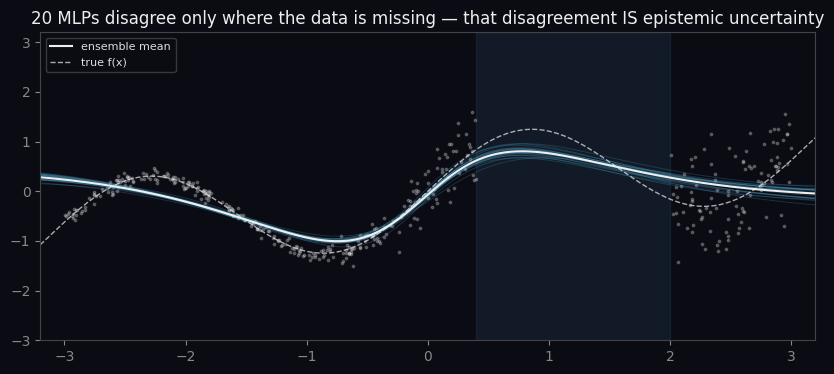

In [5]:
K = 20
ensemble = [init_mlp(hidden=48, seed=k) for k in range(K)]
rng = np.random.default_rng(123)

for k, p in enumerate(ensemble):
    boot_idx = rng.integers(0, len(X_train), size=len(X_train))
    Xk, yk = X_train[boot_idx], y_train[boot_idx]
    for t in range(4000):
        b = rng.integers(0, len(Xk), size=64)
        step_mse(p, Xk[b], yk[b], lr=5e-3)

preds = np.stack([forward(p, x_grid)[0].ravel() for p in ensemble])   # (K, N)
mu_ens  = preds.mean(0)
var_epi = preds.var(0)
sd_epi  = np.sqrt(var_epi)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(0.4, 2.0, color=CYAN, alpha=0.08)
for k in range(K):
    ax.plot(g, preds[k], color=CYAN, alpha=0.18, linewidth=0.7)
ax.plot(g, mu_ens, color=WHITE, linewidth=1.5, label='ensemble mean')
ax.plot(g, true_f(g), color=WHITE, linestyle='--', linewidth=1.0, alpha=0.7, label='true f(x)')
ax.scatter(X_train, y_train, s=3, color=WHITE, alpha=0.25)
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3, 3.2)
ax.set_title(f'{K} MLPs disagree only where the data is missing — that disagreement IS epistemic uncertainty')
ax.legend(loc='upper left', fontsize=8)
plt.show()

## 6. Measuring aleatoric uncertainty by training a noise model

An ensemble cannot capture aleatoric uncertainty. Every member trained on
enough data converges to the same conditional mean — and the *spread of
the data around that mean* is invisible to a mean-only loss like MSE.

The fix: train the network to predict the spread too. A single
heteroscedastic-NLL net outputs `(μ(x), σ²(x))`, and the NLL loss forces
the model to *report large σ² where its predictions are bad* — which, on
good data, means "where the world is genuinely noisy."

Watch what happens to the predicted `σ(x)` curve: it should grow on the
right side (where we made the noise larger) and stay flat on the left.

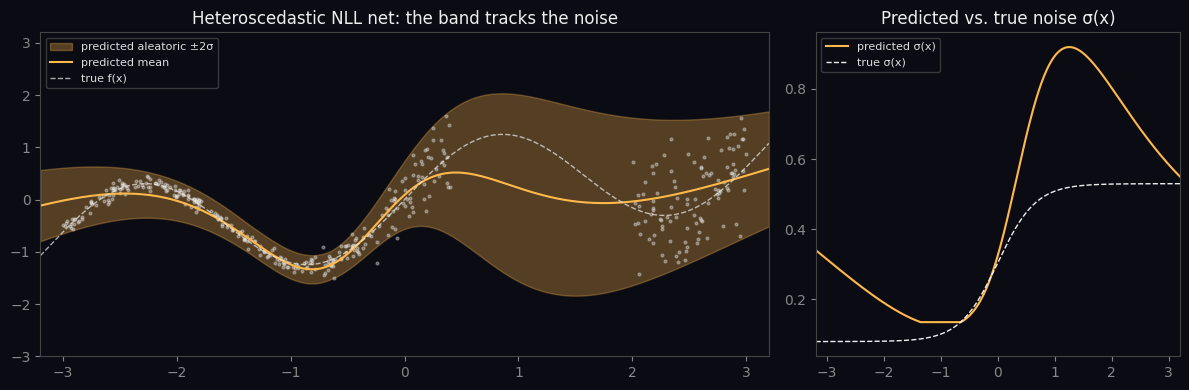

In [6]:
het = init_mlp(hidden=64, out_dim=2, seed=99, var_bias_init=-2.0)
rng = np.random.default_rng(7)
loss_curve = []
for t in range(8000):
    b = rng.integers(0, len(X_train), size=64)
    loss_curve.append(step_nll(het, X_train[b], y_train[b], lr=3e-3))

out_grid, _ = forward(het, x_grid)
mu_het   = out_grid[:, 0]
sd_alea  = np.sqrt(np.exp(np.clip(out_grid[:, 1], -4.0, 4.0)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})
ax1.fill_between(g, mu_het - 2*sd_alea, mu_het + 2*sd_alea,
                 color=GOLD, alpha=0.3, label='predicted aleatoric ±2σ')
ax1.plot(g, mu_het, color=GOLD, linewidth=1.5, label='predicted mean')
ax1.plot(g, true_f(g), color=WHITE, linestyle='--', linewidth=1.0, alpha=0.7, label='true f(x)')
ax1.scatter(X_train, y_train, s=4, color=WHITE, alpha=0.35)
ax1.set_xlim(-3.2, 3.2); ax1.set_ylim(-3, 3.2)
ax1.set_title('Heteroscedastic NLL net: the band tracks the noise')
ax1.legend(loc='upper left', fontsize=8)

ax2.plot(g, sd_alea, color=GOLD, linewidth=1.5, label='predicted σ(x)')
ax2.plot(g, noise_std(g), color=WHITE, linestyle='--', linewidth=1.0, label='true σ(x)')
ax2.set_xlim(-3.2, 3.2); ax2.set_title('Predicted vs. true noise σ(x)')
ax2.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## 7. Combining them: deep ensembles of NLL nets

Now the *principled* version. Train `K` independent heteroscedastic NLL
nets — each from a different init, each on a bootstrap sample. Each one
predicts its own `(μ_k(x), σ²_k(x))`. By the **law of total variance**
the predictive uncertainty decomposes cleanly:

$$\underbrace{\text{Var}[y \mid x]}_{\text{total}} \;=\;
\underbrace{\mathbb{E}_k[\sigma_k^2(x)]}_{\text{aleatoric}} \;+\;
\underbrace{\text{Var}_k[\mu_k(x)]}_{\text{epistemic}}.$$

The aleatoric piece comes from *averaging* each member's predicted noise
variance — every member sees the same heteroscedastic noise in their data,
so they all learn similar `σ²(x)`. The epistemic piece comes from the
*disagreement* between members' means — only large where the data is sparse.

That decomposition is the centerpiece of this notebook.

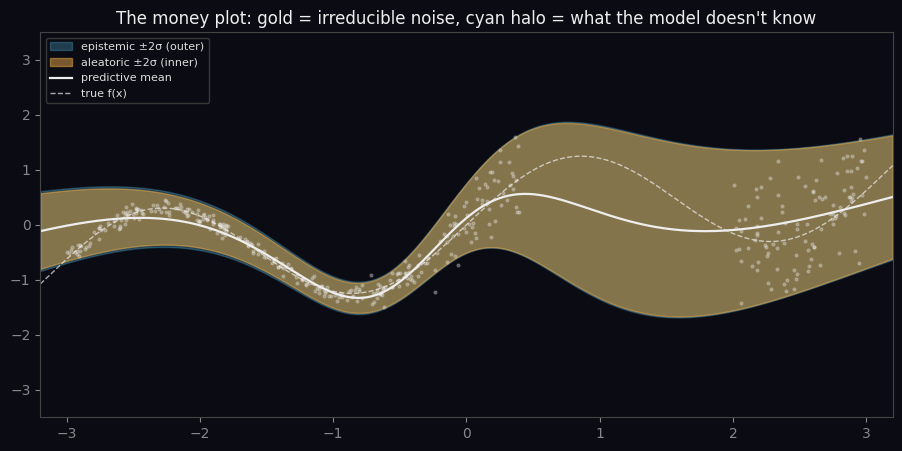

In [7]:
K = 12
ens_het = [init_mlp(hidden=64, out_dim=2, seed=1000+k, var_bias_init=-2.0)
           for k in range(K)]
rng = np.random.default_rng(31)

for k, p in enumerate(ens_het):
    boot_idx = rng.integers(0, len(X_train), size=len(X_train))
    Xk, yk = X_train[boot_idx], y_train[boot_idx]
    for t in range(8000):
        b = rng.integers(0, len(Xk), size=64)
        step_nll(p, Xk[b], yk[b], lr=3e-3)

outs = np.stack([forward(p, x_grid)[0] for p in ens_het])   # (K, N, 2)
mus  = outs[..., 0]                                          # (K, N)
vars_per_member = np.exp(np.clip(outs[..., 1], -4.0, 4.0))   # (K, N)

mu_pred  = mus.mean(0)
var_alea = vars_per_member.mean(0)              # E_k[σ²_k(x)]   — aleatoric
var_epi  = mus.var(0)                            # Var_k[μ_k(x)]  — epistemic
var_tot  = var_alea + var_epi
sd_alea, sd_epi, sd_tot = np.sqrt(var_alea), np.sqrt(var_epi), np.sqrt(var_tot)

fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(g, mu_pred - 2*sd_tot, mu_pred + 2*sd_tot,
                color=CYAN, alpha=0.25, label='epistemic ±2σ (outer)')
ax.fill_between(g, mu_pred - 2*sd_alea, mu_pred + 2*sd_alea,
                color=GOLD, alpha=0.45, label='aleatoric ±2σ (inner)')
ax.plot(g, mu_pred, color=WHITE, linewidth=1.6, label='predictive mean')
ax.plot(g, true_f(g), color=WHITE, linestyle='--', linewidth=1.0, alpha=0.7, label='true f(x)')
ax.scatter(X_train, y_train, s=4, color=WHITE, alpha=0.3)
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.5, 3.5)
ax.set_title('The money plot: gold = irreducible noise, cyan halo = what the model doesn\'t know')
ax.legend(loc='upper left', fontsize=8)
plt.show()

## 8. Reading the decomposition directly

Plotted side-by-side, the two `σ(x)` curves tell two different stories:

- **Gold rises smoothly with `x`** — that's the noise schedule we baked
  into the data. No matter how much more data we collected, the gold curve
  would stay roughly where it is.

- **Cyan bumps up inside the coverage gap** — that's the ensemble saying
  *"we're less sure what the function does in there."* The bump is modest
  because a tanh MLP has a strong smoothness prior: with data on both
  sides, it confidently interpolates across small gaps. Push the gap
  wider, shrink the bootstrap fraction, use bigger nets, or evaluate in
  the **extrapolation region** past the training domain, and the cyan
  curve grows much more dramatically. Either way, collect data in the
  missing region and the cyan curve drops; the gold curve doesn't move.


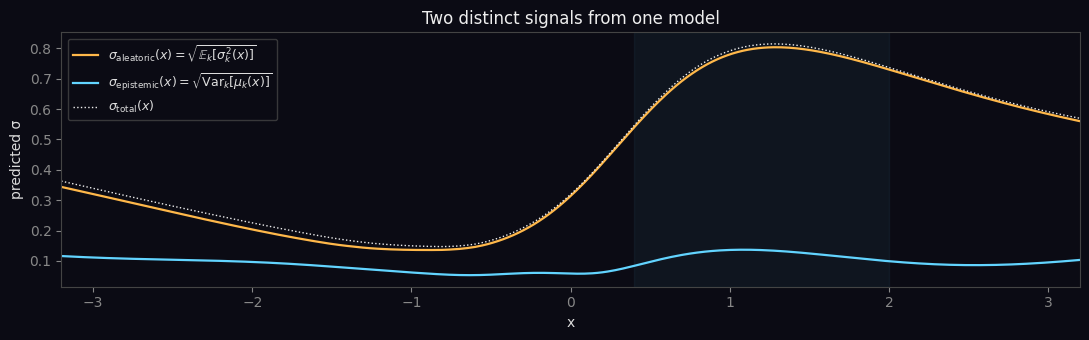

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axvspan(0.4, 2.0, color=CYAN, alpha=0.05)
ax.plot(g, sd_alea, color=GOLD, linewidth=1.6, label=r'$\sigma_{\rm aleatoric}(x) = \sqrt{\mathbb{E}_k[\sigma_k^2(x)]}$')
ax.plot(g, sd_epi,  color=CYAN, linewidth=1.6, label=r'$\sigma_{\rm epistemic}(x) = \sqrt{{\rm Var}_k[\mu_k(x)]}$')
ax.plot(g, sd_tot,  color=WHITE, linewidth=1.0, linestyle=':', label=r'$\sigma_{\rm total}(x)$')
ax.set_xlim(-3.2, 3.2); ax.set_xlabel('x'); ax.set_ylabel('predicted σ')
ax.set_title('Two distinct signals from one model')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

## 9. The same lens, pointed at an LLM

LLMs are probabilistic next-token models, but the epistemic/aleatoric
split still applies — and confusing them is the source of two very
different failure modes:

- **Aleatoric in an LLM.** Ask *"write a haiku about a cat."* There are
  millions of valid completions. The token-level distribution is broad
  *because the task is broad* — that's irreducible from the model's
  perspective. Sampling at temperature > 0 reflects this real ambiguity,
  and the right interface is *embrace it*: sample, present alternatives,
  let the user pick.

- **Epistemic in an LLM.** Ask *"what's the GDP per capita of Tuvalu in
  2024?"* There is one right answer. If the model wasn't trained on it,
  its uncertainty is purely *epistemic* — and the failure mode here is
  the most dangerous one: an LLM often hides its uncertainty behind a
  confident-sounding sentence. That is **hallucination**, and it is
  fundamentally an epistemic-uncertainty problem.

Crucially, the fix for each is different and the techniques are not
interchangeable:

- **Aleatoric → embrace it.** Sampling, n-best lists, branching UI, *"do
  you want a few options?"* Trying to be deterministic when the task
  isn't is the wrong move.
- **Epistemic → reduce it or refuse.** Retrieval (RAG), tool calls, *"I
  don't know,"* citations. All of these target *epistemic* uncertainty,
  not aleatoric.

An LLM that says *"I'm not sure"* to a creative-writing prompt is broken
in one direction; one that confabulates a Tuvalu GDP figure is broken in
the other. Same word — "uncertainty" — opposite mistake.

## 10. The same lens, pointed at predictive analytics

In a forecasting setting — churn, demand, fraud risk, sensor failures —
the split is just as load-bearing, and points at different operational
responses:

- **Aleatoric** is the *base-rate noise* of the process you're modeling.
  Customer behavior in aggregate, demand for a fast-moving SKU,
  inter-arrival times of incidents — these have inherent variance that
  more historical data won't shrink. **Plan for the variance, don't try
  to predict it away.** Confidence intervals (and decisions that respect
  them — safety stock, capacity buffers, alert thresholds) are the right
  interface.

- **Epistemic** is *what your model doesn't know about regimes it hasn't
  seen.* A demand model trained on pre-pandemic data has high epistemic
  uncertainty about post-pandemic behavior. A fraud model trained on
  card-present transactions has high epistemic uncertainty about a new
  e-commerce channel. This **is** fixable — with new data, with domain
  priors, or with a smarter model — but only if you can detect it.
  *Out-of-distribution detection is, essentially, epistemic-uncertainty
  detection.*

The practical diagnostic: if your model's error band is wide *only* on
the edges of the training distribution, that's epistemic — fight it. If
the error band is uniformly wide because the world is just noisy, that's
aleatoric — design around it.

## 11. The one-line summary

|                      | Aleatoric                          | Epistemic                              |
|----------------------|------------------------------------|----------------------------------------|
| Source               | Noise in the world / process       | Gaps in the model / data               |
| Reducible?           | No                                 | Yes                                    |
| Shrinks with data?   | No                                 | Yes                                    |
| How to measure       | Heteroscedastic NLL, quantile reg. | Ensembles, MC dropout, Bayesian methods|
| Right response       | Plan for the variance              | Collect data, retrieve, refuse         |
| In LLMs              | Open-ended generation              | Hallucinations                         |
| In analytics         | Base-rate volatility               | Regime / distribution shift            |

Both bands matter. A model that conflates them into a single
"confidence" number is, at best, useless — and at worst, dangerously
misleading. The whole point of the decomposition is that the two
uncertainties demand opposite operational responses.

## Where to take it next

- **Conformal prediction.** A distribution-free way to convert any
  point-prediction model into one with guaranteed-coverage intervals.
  Pairs nicely with the heteroscedastic mean head here.
- **Bayesian neural networks / MC dropout.** Alternative ways to get
  epistemic uncertainty without training `K` full models.
- **Evidential deep learning.** A single network that outputs both
  uncertainties at once via a Normal-Inverse-Gamma head.
- **Scale it up on the GPU.** The 12-model ensemble takes a few seconds
  on CPU; a PyTorch CUDA version with a wider net and a 100-member
  ensemble would let you do the same exercise on a real dataset (e.g.,
  a regression on UCI Boston Housing or a tabular Kaggle set) in
  about the same wall-clock time.